ResNet50 Transfer Learning on FER2013

In [1]:

import os
import copy
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision import transforms

from collections import Counter
from PIL import Image

from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
csv_path = "/kaggle/input/datasets/deadskull7/fer2013/fer2013.csv"
df = pd.read_csv(csv_path)

In [4]:
SEED = 42

torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [5]:
emotion_map = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}


In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485],
        std = [0.229]
    )
])

In [7]:
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485],
        std = [0.229]
    )
])

In [9]:
class FER2013Dataset(Dataset):

  def __init__(self, dataframe, transform= None):
    self.dataframe = dataframe
    self.transform = transform

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    row = self.dataframe.iloc[idx]

    label = int(row["emotion"])
    pixels = np.array(row["pixels"].split(), dtype=np.uint8)

    image = pixels.reshape(48,48)

    image = Image.fromarray(image)

    image= image.convert("RGB")

    if self.transform:
      image= self.transform(image)

    return image,label

In [10]:
counts= df["Usage"].value_counts()

train_df = df[df["Usage"]== "Training"].reset_index(drop=True)
val_df = df[df["Usage"]== "PublicTest"].reset_index(drop=True)
test_df = df[df["Usage"] == "PrivateTest"].reset_index(drop=True)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

train_dataset = FER2013Dataset(
    train_df,
    transform=train_transform
)

val_dataset = FER2013Dataset(
    val_df,
    transform=test_transform
)

test_dataset = FER2013Dataset(
    test_df,
    transform=test_transform
)

Training: 28709
Validation: 3589
Testing: 3589


In [11]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

LOAD PRETRAINED Efficientnet

In [12]:
from torchvision import models
import torch.nn as nn

# Load pretrained EfficientNet-B0
model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    num_features,
    7
)

# Move to device
model = model.to(device)

# Count parameters
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(model.classifier)
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Total Parameters: {total_params:,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 179MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=7, bias=True)
)
Trainable Parameters: 8,967
Total Parameters: 4,016,515


LOSS FUNCTION

In [13]:
criterion = nn.CrossEntropyLoss()


Optimizer

In [14]:
optimizer = optim.Adam(
    model.classifier[1].parameters(),
    lr= 1e-4
)
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [20]:
NUM_EPOCHS = 10
LEARNING_RATE = 0.001
BATCH_SIZE = 32

BEST_MODEL_PATH = "best_efficientnet_b0.pth"

Training function

In [21]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader, desc="Training"):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader.dataset)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [23]:
def validate_one_epoch(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in tqdm(dataloader, desc="Validation"):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [24]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs,
    device
):

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_acc = 0.0

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc = validate_one_epoch(
            model,
            val_loader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Train Loss : {train_loss:.4f}")
        print(f"Train Acc  : {train_acc:.4f}")
        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val Acc    : {val_acc:.4f}")

        if val_acc > best_val_acc:

            best_val_acc = val_acc

            torch.save(model.state_dict(), "best_efficientnet_b0.pth")

            print("Best model saved.")

    return history

In [25]:
history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    NUM_EPOCHS,
    device
)


Epoch 1/10


Training:   0%|          | 0/898 [00:00<?, ?it/s]

Validation:   0%|          | 0/113 [00:00<?, ?it/s]

Train Loss : 1.7395
Train Acc  : 0.3053
Val Loss   : 1.6877
Val Acc    : 0.3391
Best model saved.

Epoch 2/10


Training:   0%|          | 0/898 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/113 [00:00<?, ?it/s]

Train Loss : 1.5174
Train Acc  : 0.4175
Val Loss   : 1.5231
Val Acc    : 0.4238
Best model saved.

Epoch 10/10


Training:   0%|          | 0/898 [00:00<?, ?it/s]

Validation:   0%|          | 0/113 [00:00<?, ?it/s]

Train Loss : 1.5089
Train Acc  : 0.4209
Val Loss   : 1.5103
Val Acc    : 0.4338
Best model saved.


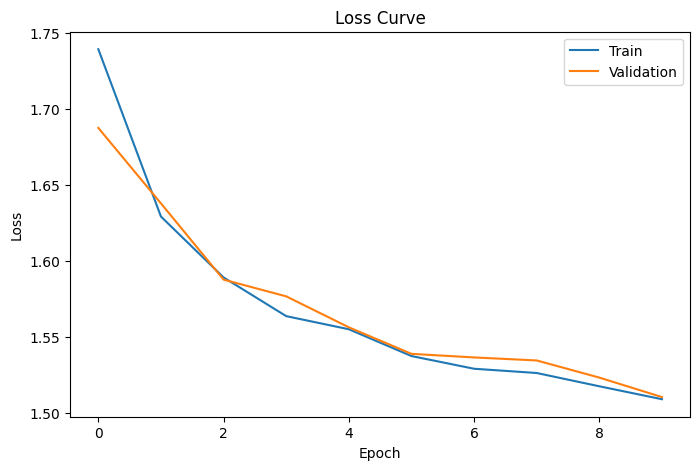

<Figure size 640x480 with 0 Axes>

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()

plt.show()

plt.savefig("/kaggle/working/plots/efficient_b0_loss.png",
            dpi=300,
            bbox_inches="tight")


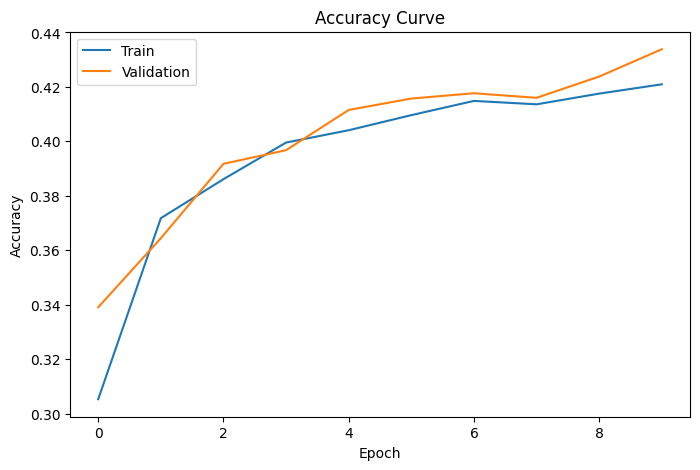

<Figure size 640x480 with 0 Axes>

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()

plt.show()

plt.savefig("/kaggle/working/plots/efficientnet_b0_accuracy.png",
            dpi=300,
            bbox_inches="tight")

MODEL EVALUATION

In [ ]:
def evaluate_model(model, dataloader, device):

    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in tqdm(dataloader, desc="Evaluating"):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(preds.cpu().numpy())

    return all_labels, all_predictions

In [28]:
def evaluate_model(model, dataloader, device):

    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in tqdm(dataloader, desc="Evaluating"):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(preds.cpu().numpy())

    return all_labels, all_predictions

In [29]:
y_true, y_pred = evaluate_model(
    model,
    test_loader,
    device
)

Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

In [30]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.4227
Precision: 0.3998
Recall   : 0.4227
F1 Score : 0.3952


In [31]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=[
        "Angry",
        "Disgust",
        "Fear",
        "Happy",
        "Sad",
        "Surprise",
        "Neutral"
    ]
))

              precision    recall  f1-score   support

       Angry       0.38      0.25      0.30       491
     Disgust       0.00      0.00      0.00        55
        Fear       0.28      0.14      0.19       528
       Happy       0.45      0.77      0.57       879
         Sad       0.35      0.37      0.36       594
    Surprise       0.59      0.55      0.57       416
     Neutral       0.39      0.31      0.35       626

    accuracy                           0.42      3589
   macro avg       0.35      0.34      0.33      3589
weighted avg       0.40      0.42      0.40      3589



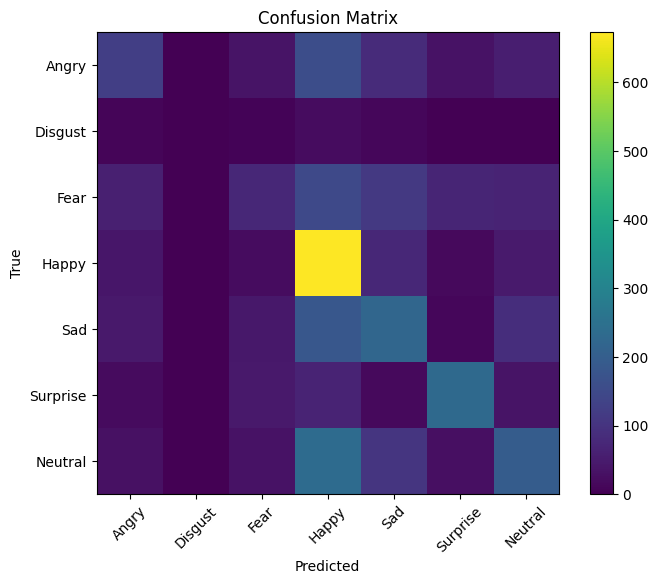

<Figure size 640x480 with 0 Axes>

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

plt.imshow(cm, interpolation="nearest")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(range(7), emotion_map.values(), rotation=45)
plt.yticks(range(7), emotion_map.values())

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

plt.savefig("/kaggle/working/confusion_matrices/efficient_b0_cm.png",
            dpi=300,
            bbox_inches="tight")

In [19]:
import os

# Create output folders
folders = [
    "/kaggle/working/plots",
    "/kaggle/working/confusion_matrices",
    "/kaggle/working/reports",
    "/kaggle/working/results"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [58]:
import os

print(os.listdir("/kaggle/working"))

['reports', 'plots', 'best_resnet50.pth', '.virtual_documents', 'results', 'confusion_matrices']


In [34]:
class_names = [emotion_map[i] for i in range(len(emotion_map))]
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

with open("/kaggle/working/reports/efficient_b0_report.txt", "w") as f:
    f.write(report)

              precision    recall  f1-score   support

       Angry       0.38      0.25      0.30       491
     Disgust       0.00      0.00      0.00        55
        Fear       0.28      0.14      0.19       528
       Happy       0.45      0.77      0.57       879
         Sad       0.35      0.37      0.36       594
    Surprise       0.59      0.55      0.57       416
     Neutral       0.39      0.31      0.35       626

    accuracy                           0.42      3589
   macro avg       0.35      0.34      0.33      3589
weighted avg       0.40      0.42      0.40      3589

